<a href="https://colab.research.google.com/github/szabeebzaliz7-a11y/Datascience-And-Gen-AI/blob/main/Assignment_05_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective: The main objective of this project is to design and implement a robust data
preprocessing system that addresses common challenges such as missing values, outliers,
inconsistent formatting, and noise.
By performing effective data preprocessing, the project aims to enhance the quality, reliability,
and usefulness of the data for machine learning.

Dataset:
https://drive.google.com/file/d/1F3lRf32JM8ejnXq-Cbf9y7fa57zSHGz_/view?usp=sharing

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
df=pd.read_csv('Employee.csv')

In [88]:
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [89]:
df[['Company','Age','Salary','Place','Country','Gender']].nunique()

,0
Company,6
Age,29
Salary,40
Place,11
Country,1
Gender,2


1. Data Exploration:
● Explore the data, list down the unique values in each feature and find its length.
● Perform the statistical analysis and renaming of the columns.

In [90]:
for column in df.columns:
  if df[column].dtype=='object':
    print(f"\nColumn: {column}")
    unique_values=df[column].unique()
    print(f"Unique values: {unique_values}")
    print(f"Count of unique values: {len(unique_values)}")


Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Count of unique values: 7

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Count of unique values: 12

Column: Country
Unique values: ['India']
Count of unique values: 1


In [91]:
print(df.describe())

              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.096640  2573.764683    0.417654
min      0.000000  1089.000000    0.000000
25%     22.000000  3030.000000    0.000000
50%     32.500000  5000.000000    0.000000
75%     37.750000  8000.000000    0.000000
max     54.000000  9876.000000    1.000000


In [92]:
print(df.columns)

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')


2. Data Cleaning:
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [94]:
df.isnull().sum()

,0
Company,8
Age,18
Salary,24
Place,14
Country,0
Gender,0


In [95]:
df['Company'].isnull().sum()

np.int64(8)

In [96]:
df['Company'].fillna(df['Company'].mode(),inplace=True)

/tmp/ipython-input-2954410459.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Company'].fillna(df['Company'].mode(),inplace=True)


In [97]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [98]:
df['Salary']=df['Salary'].fillna(df['Salary'].median())

In [99]:
df['Place']=df['Place'].fillna(method='ffill')

/tmp/ipython-input-3395822469.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Place']=df['Place'].fillna(method='ffill')


In [100]:
df[df.duplicated()]

,Company,Age,Salary,Place,Country,Gender
41,Infosys,30.484615,5000.0,Calcutta,India,0
78,TCS,30.484615,6000.0,Calcutta,India,0
84,CTS,43.000000,5000.0,Mumbai,India,0
130,TCS,21.000000,4824.0,Mumbai,India,0
131,Infosys,30.484615,5835.0,Mumbai,India,0
144,Infosys,22.000000,8787.0,Calcutta,India,1


In [101]:
df.drop_duplicates(inplace=True)

In [102]:
df[df.duplicated()]

,Company,Age,Salary,Place,Country,Gender


<Axes: >

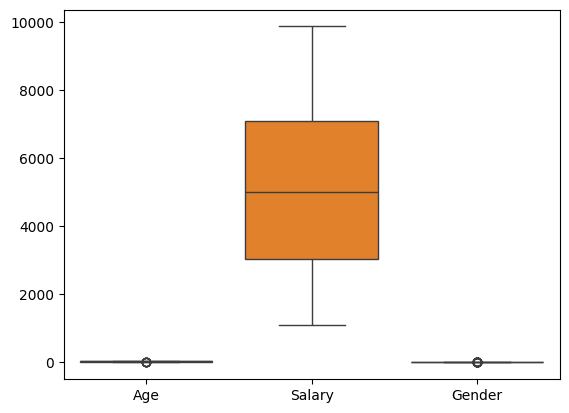

In [103]:
sns.boxplot(df)

<Axes: ylabel='Company'>

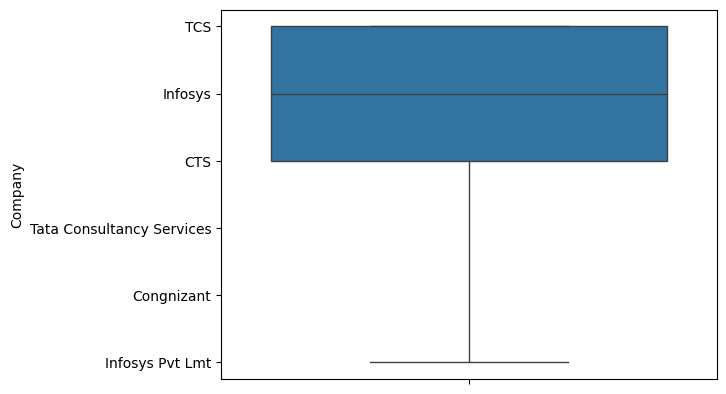

In [104]:
sns.boxplot(df['Company'])

<Axes: ylabel='Place'>

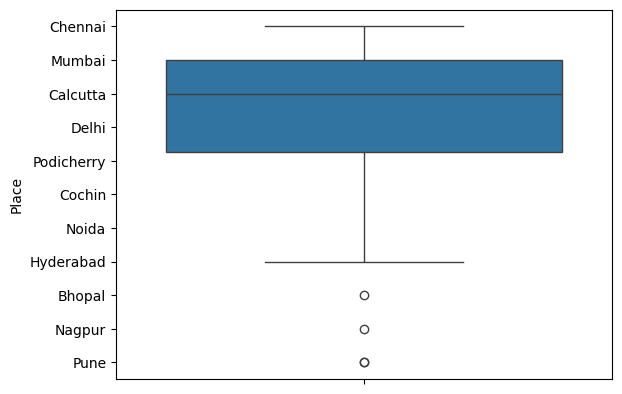

In [105]:
sns.boxplot(df['Place'])

3. Data Analysis:
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

In [106]:
age_salary=df[(df['Age']>40) & (df['Salary']<5000)]
print("Filtered DataFrame (age_salary) head:")
print(age_salary.head())
print("\nShape of the filtered DataFrame:", age_salary.shape)

Filtered DataFrame (age_salary) head:
    Company   Age  Salary      Place Country  Gender
21  Infosys  50.0  3184.0      Delhi   India       0
32  Infosys  45.0  4034.0   Calcutta   India       0
39  Infosys  41.0  3000.0     Mumbai   India       0
50  Infosys  41.0  3000.0    Chennai   India       0
57  Infosys  51.0  3184.0  Hyderabad   India       0

Shape of the filtered DataFrame: (15, 6)


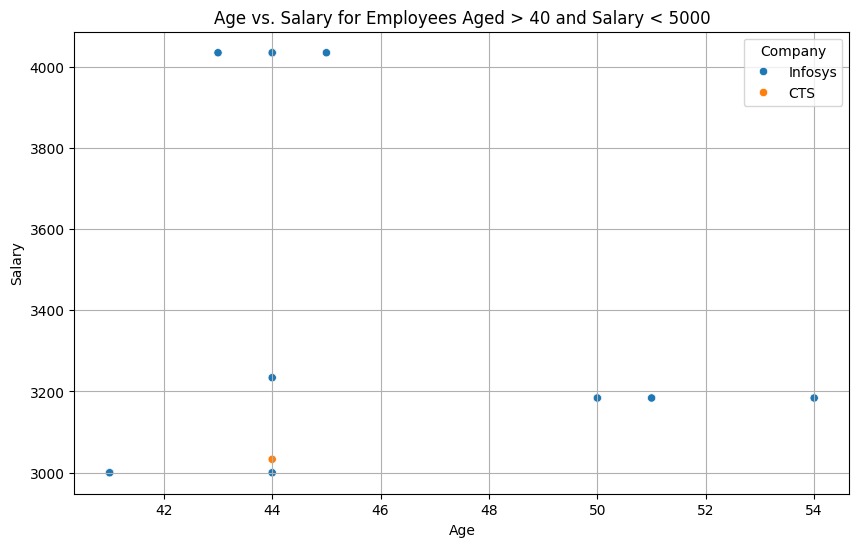

In [107]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=age_salary, x='Age', y='Salary', hue='Company')
plt.title('Age vs. Salary for Employees Aged > 40 and Salary < 5000')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

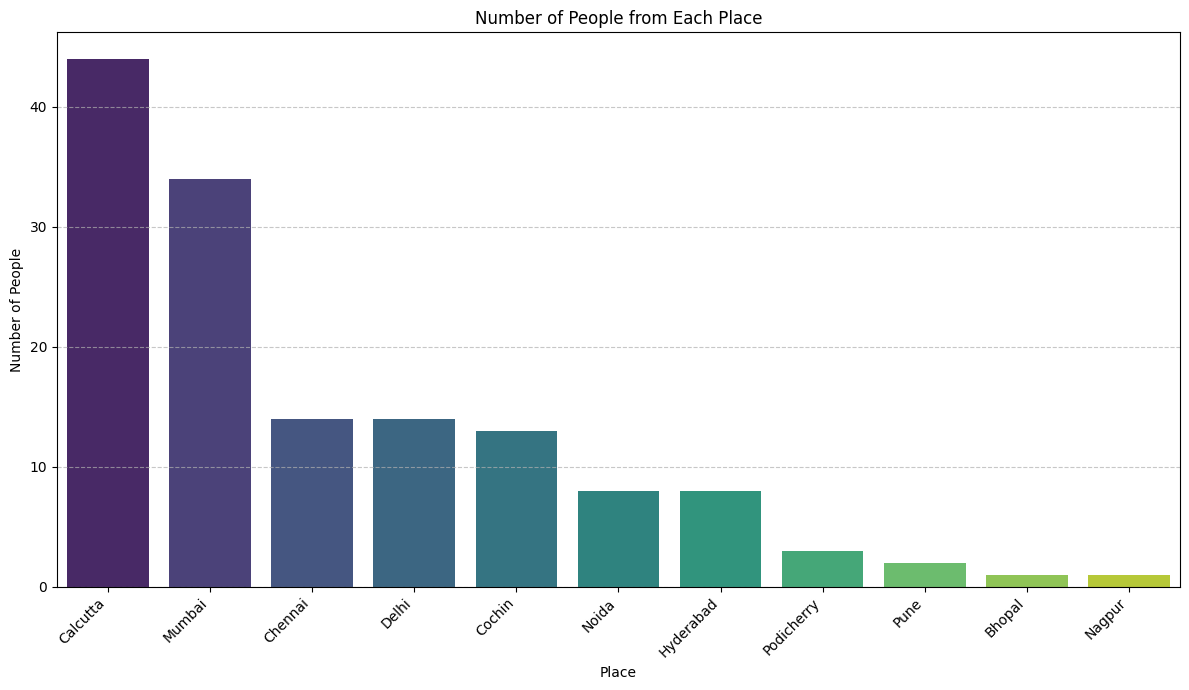

In [108]:
place_counts = df['Place'].value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=place_counts.index, y=place_counts.values, hue=place_counts.index, palette='viridis', legend=False)
plt.title('Number of People from Each Place')
plt.xlabel('Place')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

4. Data Encoding:
● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [109]:
df['Company'].unique()

array(['TCS', 'Infosys', 'CTS', nan, 'Tata Consultancy Services',
       'Congnizant', 'Infosys Pvt Lmt'], dtype=object)

In [110]:
df['Place'].unique()

array(['Chennai', 'Mumbai', 'Calcutta', 'Delhi', 'Podicherry', 'Cochin',
       'Noida', 'Hyderabad', 'Bhopal', 'Nagpur', 'Pune'], dtype=object)

In [111]:
df['Country'].unique()

array(['India'], dtype=object)

In [112]:
Country_Encoded=pd.get_dummies(df['Country'],dtype=int)
df=pd.concat([df,Country_Encoded],axis=1)

In [113]:
df

,Company,Age,Salary,Place,Country,Gender,India
0,TCS,20.0,5000.0,Chennai,India,0,1
1,Infosys,30.0,5000.0,Mumbai,India,0,1
2,TCS,35.0,2300.0,Calcutta,India,0,1
3,Infosys,40.0,3000.0,Delhi,India,0,1
4,TCS,23.0,4000.0,Mumbai,India,0,1
...,...,...,...,...,...,...,...
142,Infosys Pvt Lmt,22.0,8202.0,Mumbai,India,0,1
143,TCS,33.0,9024.0,Calcutta,India,1,1
145,Infosys,44.0,4034.0,Delhi,India,1,1
146,TCS,33.0,5034.0,Mumbai,India,1,1


In [114]:
df.drop('Country',axis=1,inplace=True)

In [115]:
df

,Company,Age,Salary,Place,Gender,India
0,TCS,20.0,5000.0,Chennai,0,1
1,Infosys,30.0,5000.0,Mumbai,0,1
2,TCS,35.0,2300.0,Calcutta,0,1
3,Infosys,40.0,3000.0,Delhi,0,1
4,TCS,23.0,4000.0,Mumbai,0,1
...,...,...,...,...,...,...
142,Infosys Pvt Lmt,22.0,8202.0,Mumbai,0,1
143,TCS,33.0,9024.0,Calcutta,1,1
145,Infosys,44.0,4034.0,Delhi,1,1
146,TCS,33.0,5034.0,Mumbai,1,1


In [116]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Company']=le.fit_transform(df['Company'])
df['Place']=le.fit_transform(df['Place'])

In [117]:
df

,Company,Age,Salary,Place,Gender,India
0,4,20.0,5000.0,2,0,1
1,2,30.0,5000.0,6,0,1
2,4,35.0,2300.0,1,0,1
3,2,40.0,3000.0,4,0,1
4,4,23.0,4000.0,6,0,1
...,...,...,...,...,...,...
142,3,22.0,8202.0,6,0,1
143,4,33.0,9024.0,1,1,1
145,2,44.0,4034.0,4,1,1
146,4,33.0,5034.0,6,1,1


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  142 non-null    int64  
 1   Age      142 non-null    float64
 2   Salary   142 non-null    float64
 3   Place    142 non-null    int64  
 4   Gender   142 non-null    int64  
 5   India    142 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 7.8 KB


5. Feature Scaling:
● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [123]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [124]:
min_max_scaler=MinMaxScaler()
standard_scaler=StandardScaler()

In [126]:
x=df
x=min_max_scaler.fit_transform(x)

In [129]:
normalisation = MinMaxScaler()
x=normalisation.fit_transform(x)
x=pd.DataFrame(x)
x.describe()

,0,1,2,3,4,5
count,142.000000,142.000000,142.000000,142.000000,142.000000,142.0
mean,0.415493,0.565241,0.471777,0.372535,0.225352,0.0
std,0.300870,0.194572,0.271588,0.252405,0.419293,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.166667,0.425926,0.222602,0.100000,0.000000,0.0
50%,0.333333,0.583333,0.445089,0.300000,0.000000,0.0
75%,0.666667,0.666667,0.682258,0.600000,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [130]:
x=standard_scaler.fit_transform(x)
x=pd.DataFrame(x)
x.describe()

,0,1,2,3,4,5
count,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,142.0
mean,-6.411147e-17,-3.815414e-16,-3.189937e-16,-1.188408e-16,-3.752867e-17,0.0
std,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,0.0
min,-1.385861e+00,-2.915330e+00,-1.743254e+00,-1.481165e+00,-5.393599e-01,0.0
25%,-8.299506e-01,-7.185426e-01,-9.207236e-01,-1.083575e+00,-5.393599e-01,0.0
50%,-2.740403e-01,9.331353e-02,-9.861406e-02,-2.883932e-01,-5.393599e-01,0.0
75%,8.377804e-01,5.231197e-01,7.777421e-01,9.043788e-01,-5.393599e-01,0.0
max,1.949601e+00,2.242344e+00,1.951824e+00,2.494742e+00,1.854050e+00,0.0
